In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set_style("whitegrid")

df = pd.read_csv("/Users/hinahaq/Downloads/amz_uk_price_prediction_dataset.csv")
df.columns = df.columns.str.strip().str.lower()
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")
df = df.dropna(subset=["price", "stars", "category"]).copy()

### Part 1: Analyzing Best-Seller Trends Across Product Categories


Top Best-Seller Categories (%):
 isbestseller                     False   True 
category                                      
Grocery                         0.9419  0.0581
Smart Home Security & Lighting  0.9423  0.0577
Health & Personal Care          0.9423  0.0577
Mobile Phone Accessories        0.9575  0.0425
Power & Hand Tools              0.9647  0.0353
Billiard, Snooker & Pool        0.9679  0.0321
Pet Supplies                    0.9698  0.0302
Home Brewing & Wine Making      0.9715  0.0285
Wind Instruments                0.9720  0.0280
Mirrors                         0.9720  0.0280

Chi²: 36540.20, p-value: 0.00e+00 → REJECT independence (p<0.05)
Cramér's V: 0.007 (weak-moderate assoc.)


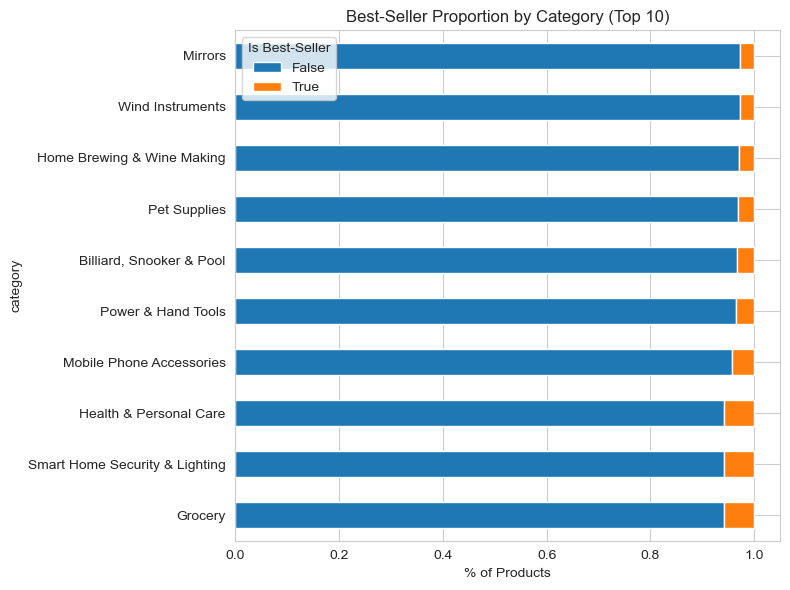

In [4]:
# 1. Crosstab + Proportions (Top 10)
crosstab = pd.crosstab(df['category'], df['isbestseller'], normalize='index')
best_prop = crosstab.sort_values(True, ascending=False).head(10)
print("Top Best-Seller Categories (%):\n", best_prop.round(4))

# 2. Chi-Square Test (independence?)
from scipy.stats import chi2_contingency
chi2_table = pd.crosstab(df['category'], df['isbestseller'])
chi2, p, dof, expected = chi2_contingency(chi2_table)
print(f"\nChi²: {chi2:.2f}, p-value: {p:.2e} → REJECT independence (p<0.05)")

# Cramér's V (association strength)
n = chi2_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (chi2_table.shape[0] - 1)))
print(f"Cramér's V: {cramers_v:.3f} (weak-moderate assoc.)")

# 3. Stacked Bar Viz
best_prop.head(10).plot(kind='barh', stacked=True, figsize=(8,6))
plt.title("Best-Seller Proportion by Category (Top 10)")
plt.xlabel("% of Products")
plt.legend(title="Is Best-Seller")
plt.tight_layout()
plt.show()

Grocery (5.81%) leads best-sellers; Chi² rejects independence (p=0), Cramér's V=0.007 (weak assoc.) target Grocery/Smart Home.

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

In [6]:
# IQR Outlier Removal
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Price: Q1=£{Q1:.2f}, Q3=£{Q3:.2f}, IQR=£{IQR:.2f}")
print(f"Bounds: £{lower:.2f} - £{upper:.2f}")
print(f"Outliers: {((df['price'] < lower) | (df['price'] > upper)).sum():,}")

df_clean = df[(df['price'] >= lower) & (df['price'] <= upper)].copy()
print(f"Clean shape: {df_clean.shape}")

Price: Q1=£9.99, Q3=£45.99, IQR=£36.00
Bounds: £-44.01 - £99.99
Outliers: 327,688
Clean shape: (2115963, 9)


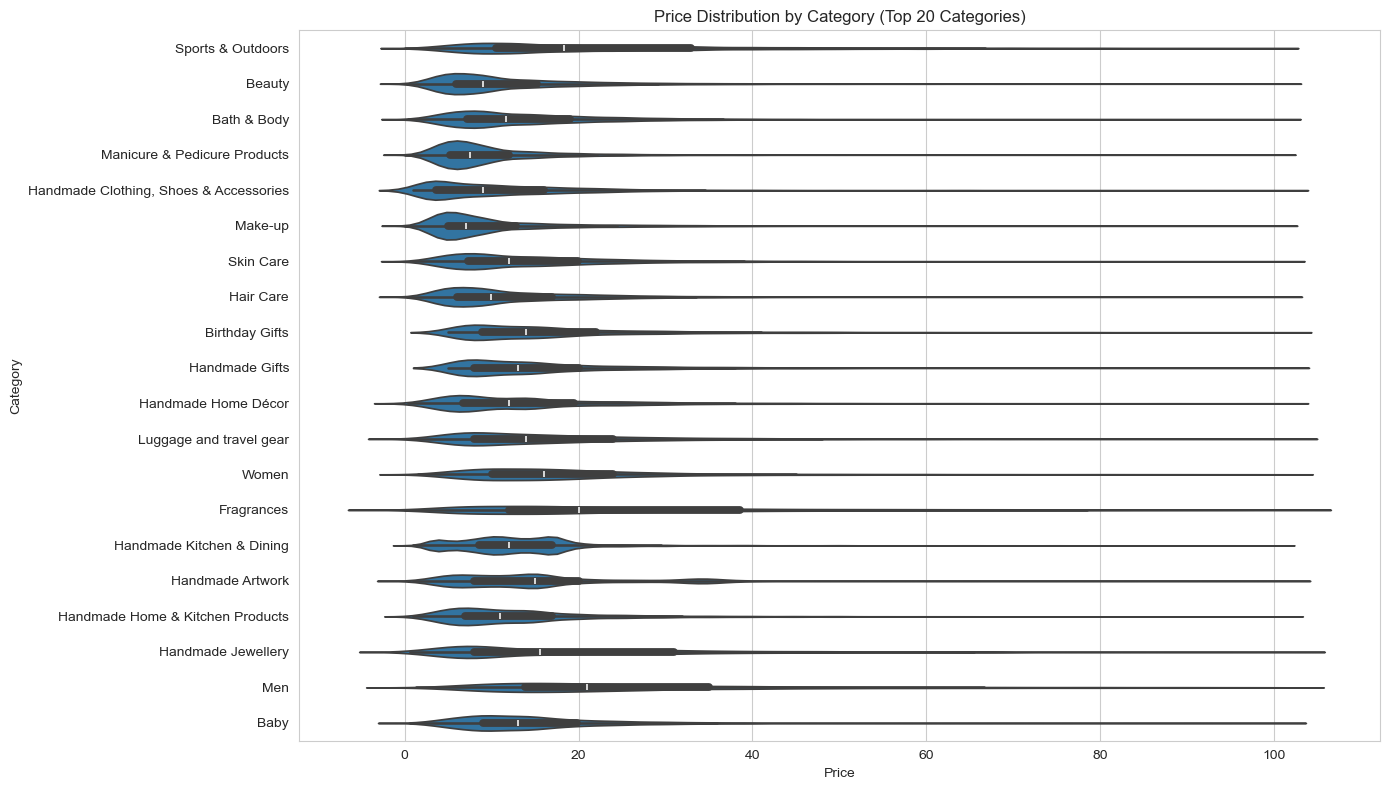

In [ ]:
#violin
top20_categories = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top20_categories)].copy()

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_top20, x='price', y='category', order=top20_categories)
plt.title('Price Distribution by Category (Top 20 Categories)')
plt.xlabel('Price')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

The violin plot shows that product prices are mostly concentrated at the lower end across categories, with a few categories like Sports & Outdoors and Fragrances showing wider price spreads and higher median prices.

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64


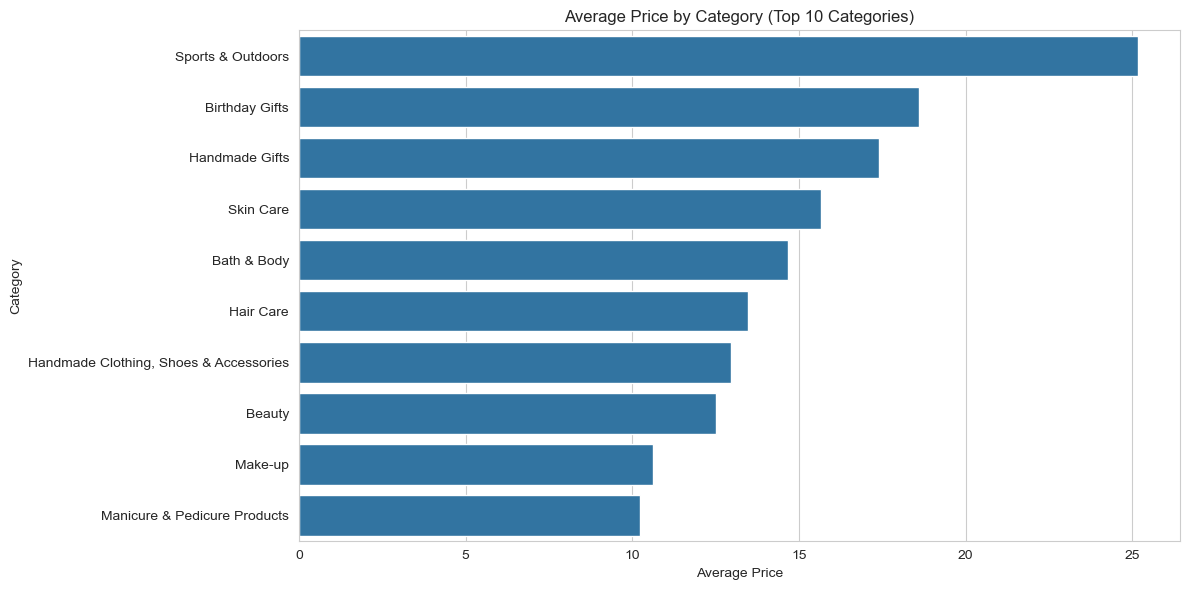

In [8]:
#Barplot
top10_categories = df_clean['category'].value_counts().head(10).index
avg_price_top10 = (
    df_clean[df_clean['category'].isin(top10_categories)]
    .groupby('category')['price']
    .mean()
    .sort_values(ascending=False)
)

print(avg_price_top10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_top10.values, y=avg_price_top10.index)
plt.title('Average Price by Category (Top 10 Categories)')
plt.xlabel('Average Price')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

The bar chart shows that Sports & Outdoors has the highest average price among the top 10 categories by count, followed by Birthday Gifts and Handmade Gifts.

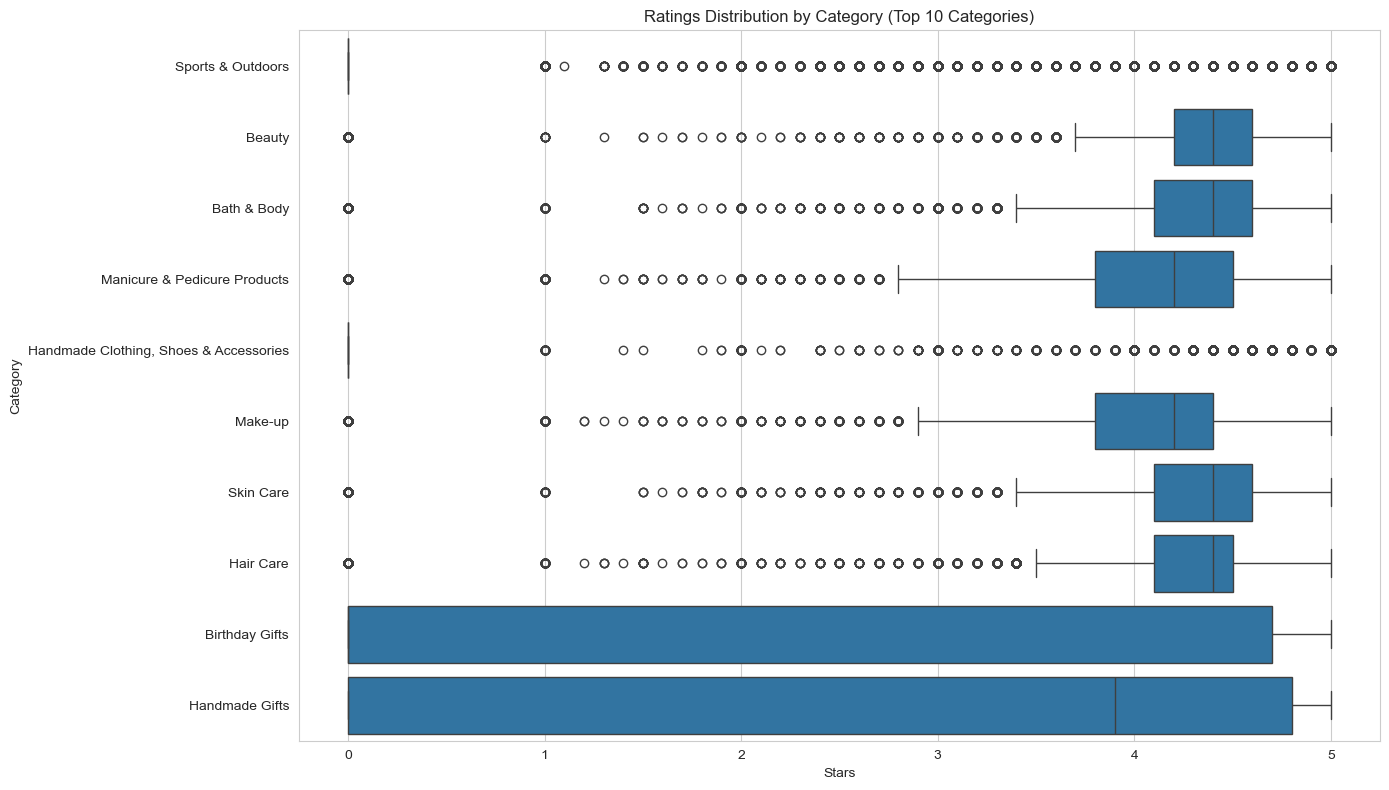

In [9]:
#boxplot
top10_categories = df_clean['category'].value_counts().head(10).index
df_top10 = df_clean[df_clean['category'].isin(top10_categories)].copy()

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top10, x='stars', y='category', order=top10_categories)
plt.title('Ratings Distribution by Category (Top 10 Categories)')
plt.xlabel('Stars')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

The box plot shows that categories like Beauty, Bath & Body, Skin Care, and Hair Care tend to have higher median ratings, while categories such as Sports & Outdoors have lower or more limited rating distributions in this sample.

In [11]:
median_ratings = df_clean.groupby('category')['stars'].median().sort_values(ascending=False)
print(median_ratings.head(10))

top_median_category = median_ratings.index[0]
top_median_value = median_ratings.iloc[0]

print(f"Category with highest median rating: {top_median_category}")
print(f"Highest median rating: {top_median_value}")

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64
Category with highest median rating: Computer Memory
Highest median rating: 4.7


Computer Memory has the highest median customer rating, with a median of 4.7 stars.

### Part 3: Investigating the Interplay Between Product Prices and Ratings

Correlation between price and stars: -0.0777
P-value: 0.0000


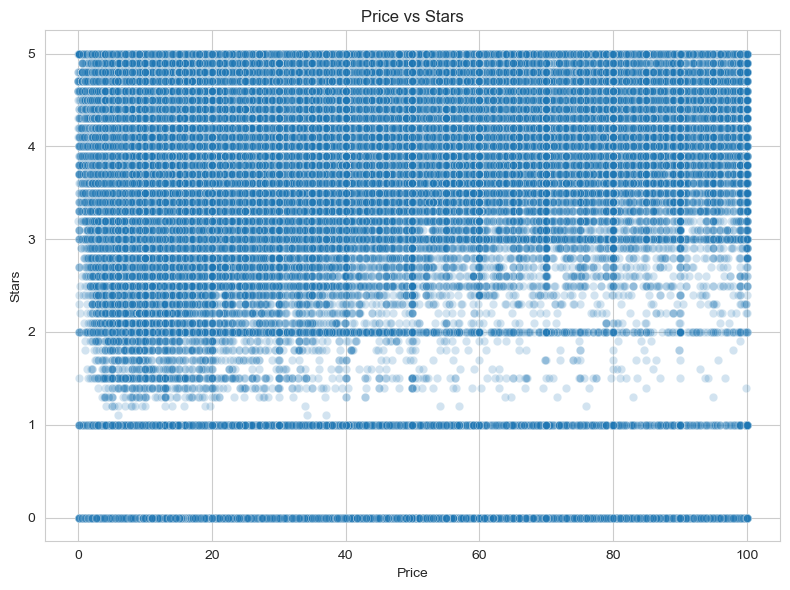

In [12]:
from scipy.stats import pearsonr, probplot

corr_coef, p_value = pearsonr(df_clean['price'], df_clean['stars'])
print(f"Correlation between price and stars: {corr_coef:.4f}")
print(f"P-value: {p_value:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='price', y='stars', alpha=0.2)
plt.title('Price vs Stars')
plt.xlabel('Price')
plt.ylabel('Stars')
plt.tight_layout()
plt.show()

The scatter plot shows a very weak negative relationship between price and stars, meaning higher-priced products do not tend to have higher ratings.

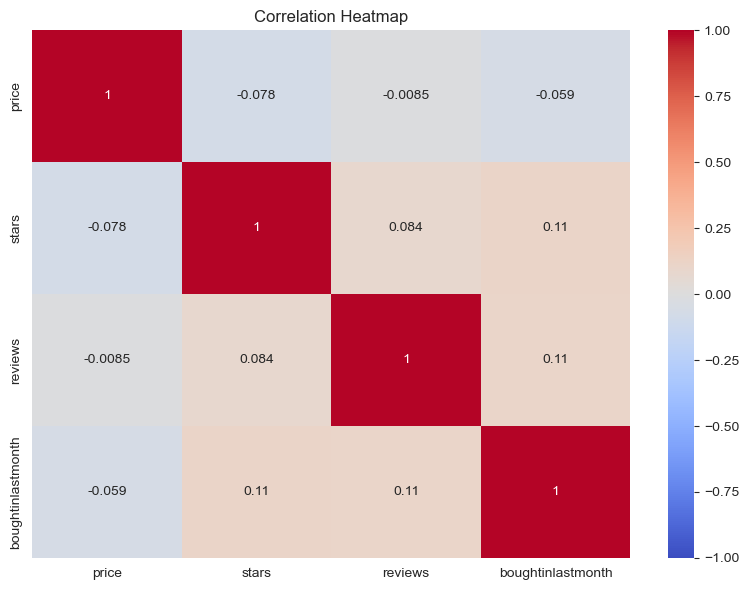

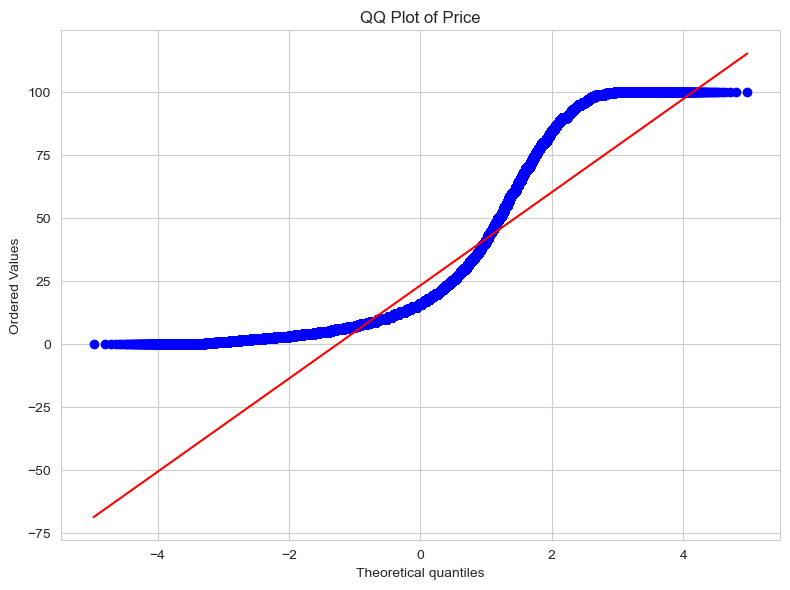

In [13]:
# Correlation heatmap
numeric_df = df_clean[['price', 'stars', 'reviews', 'boughtinlastmonth']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# QQ plot for price
from scipy import stats

plt.figure(figsize=(8, 6))
stats.probplot(df_clean['price'], dist="norm", plot=plt)
plt.title('QQ Plot of Price')
plt.tight_layout()
plt.show()

Price and stars have a very weak negative relationship, and the QQ plot shows that price is not normally distributed.

**Conclusion**
Overall, best-seller status varies by category, with Grocery showing the highest best-seller proportion, although the association is weak. Prices differ across categories, with Sports & Outdoors having the highest average price among the top 10 categories, while Computer Memory has the highest median rating. Finally, price and stars show only a very weak negative correlation, and the price distribution is not normal.